<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [13]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


<function matplotlib.pyplot.show(close=None, block=None)>

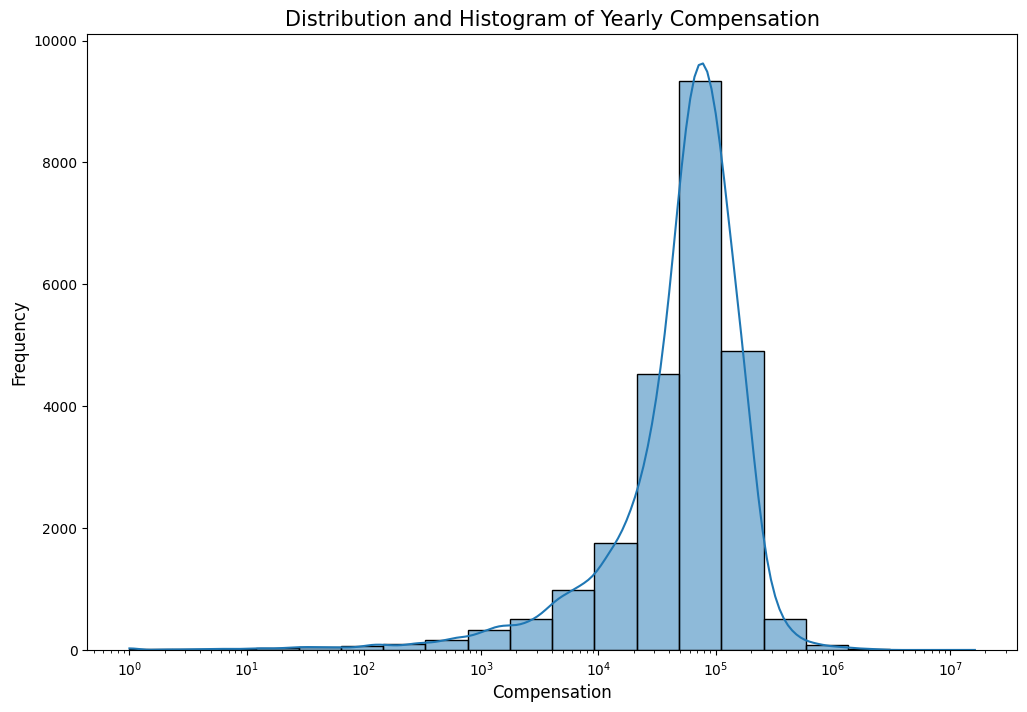

In [14]:
## Write your code here
#Create histogram with a KDE curve
plt.figure(figsize=(12, 8))
sns.histplot(df['ConvertedCompYearly'], kde=True, bins = 20, log_scale=True)

#Add labels and title
plt.title('Distribution and Histogram of Yearly Compensation', fontsize=15)
plt.xlabel('Compensation', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [15]:
## Write your code here
#Calculate median compensation for full time employees
#First need to filter data for Employed, full-time
full_time_df = df[df['Employment'] == 'Employed, full-time']

#Now can calculate median comp from down selected dataframe
median_comp = full_time_df['ConvertedCompYearly'].median() 

print(f'The median compensation of all employees is {df['ConvertedCompYearly'].median()}')
print(f'The median compensation of full time employees is {median_comp}')

The median compensation of all employees is 65000.0
The median compensation of full time employees is 69814.0


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



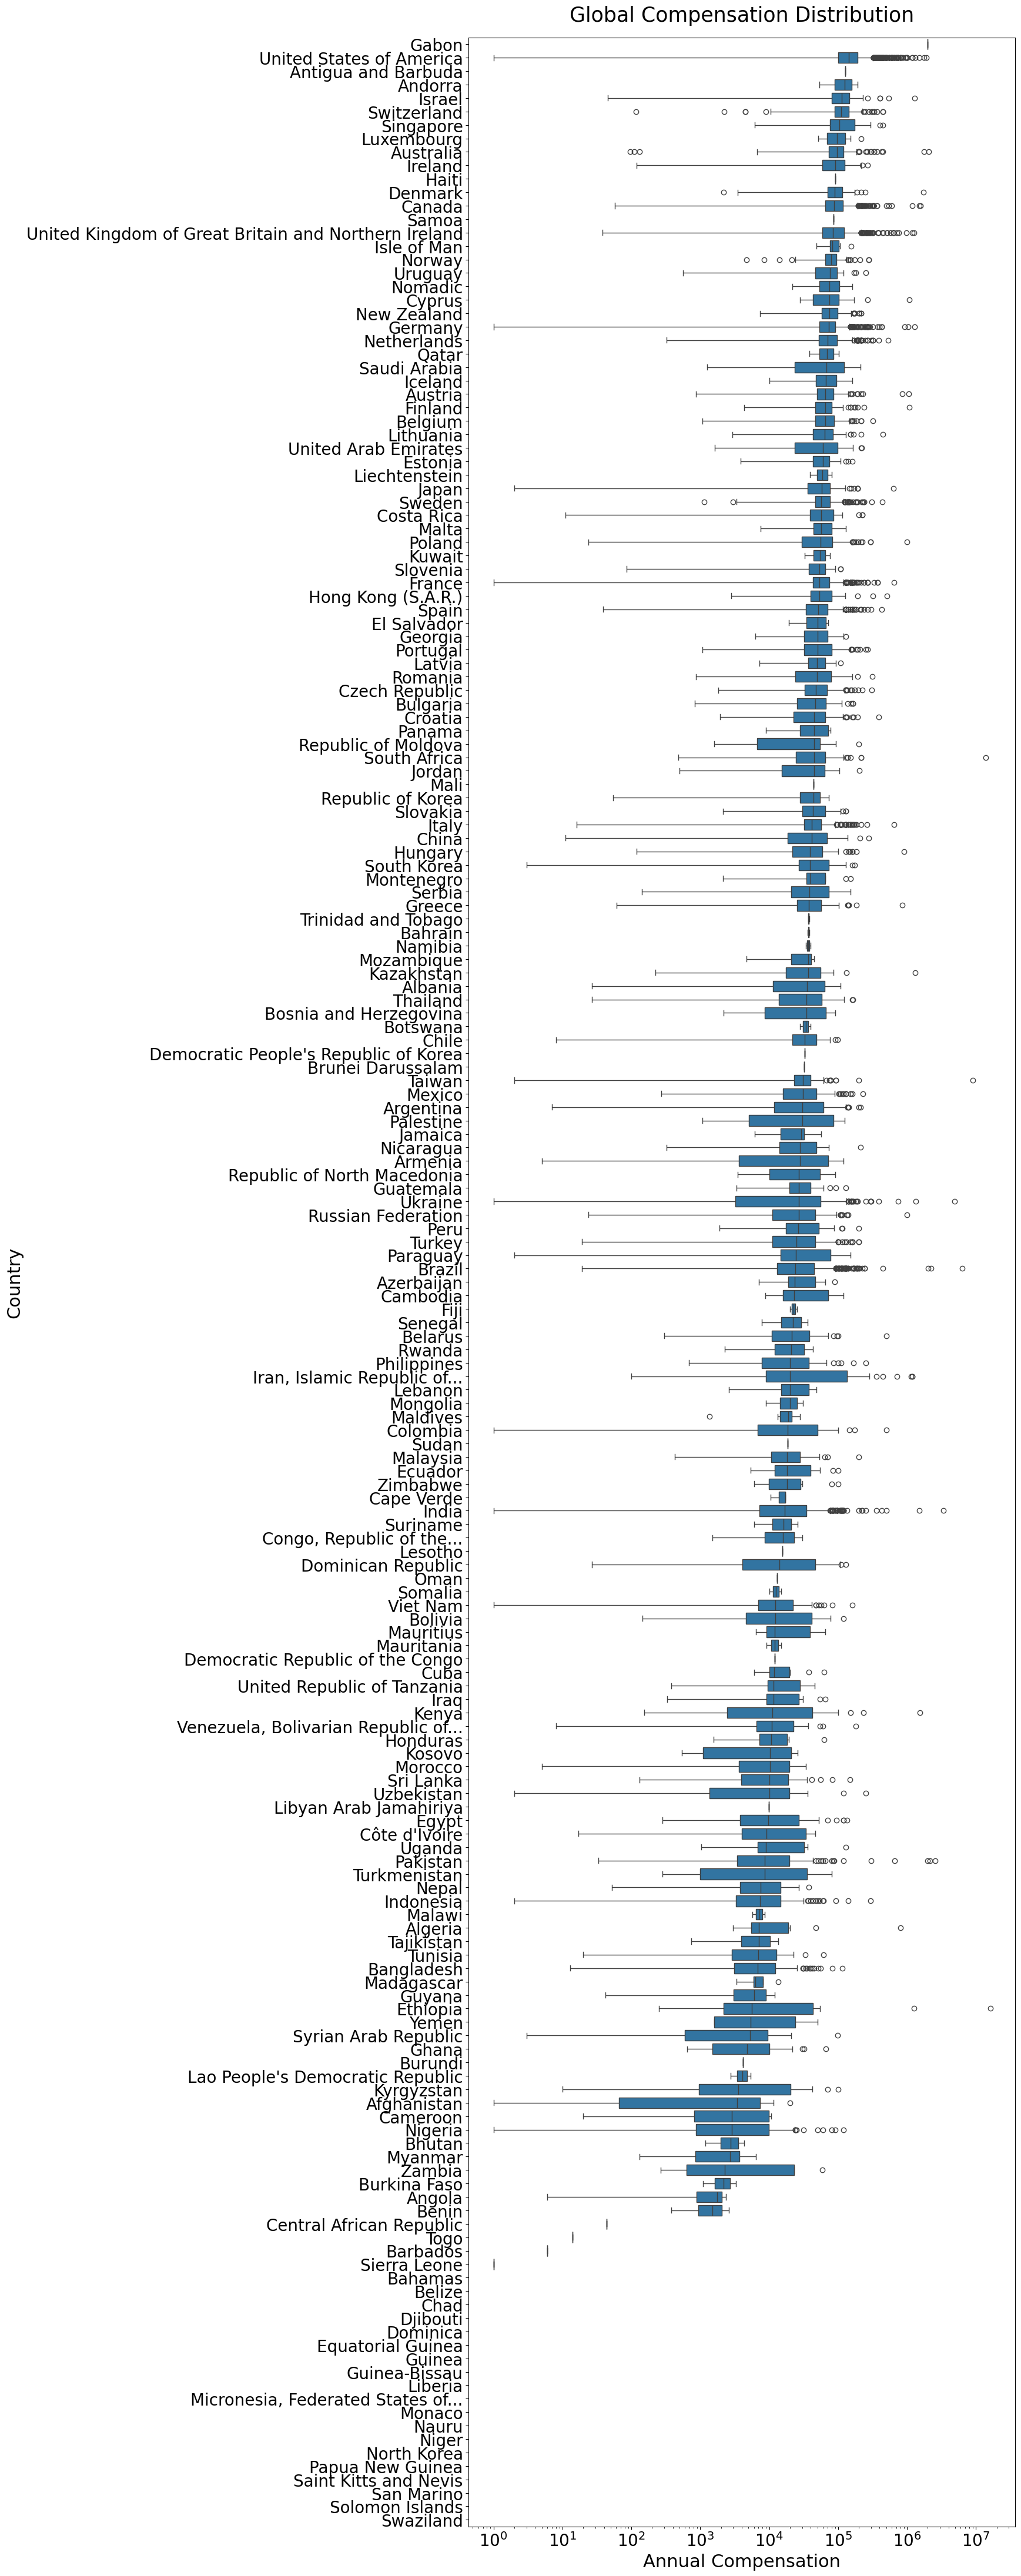

In [16]:
## Write your code here
#Groupby country and sort by median salary
country_comp = df.groupby('Country')['ConvertedCompYearly'].median().sort_values(ascending=False).index

#Plot box plots
plt.figure(figsize = (12, 55)) #long figure

#Set the figure as a box plot
ax = sns.boxplot(data = df, x='ConvertedCompYearly', y='Country', order = country_comp)

#Use log scale for x axis
ax.set_xscale('log')

#Add title and labels
plt.yticks(fontsize=10)
plt.title('Global Compensation Distribution', fontsize=25, pad=20)
plt.xlabel('Annual Compensation', fontsize=22)
plt.ylabel('Country', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [17]:
## Write your code here

#First need to remove nan's from ConvertedCompYearly column
!pip install numpy
import numpy as np
df = df.dropna(subset=['ConvertedCompYearly'])

#calculate first (25%) and third (75%) quartiles for ConvertedCompYearly
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
print(f'Yearly comp 25th percentile is {Q1}, and 75th percentile is {Q3}')

#calculate Interquartile Range (IQR) for ConvertedCompYearly
IQR = Q3-Q1
print(f'Yearly comp 25th Interquartile Range is {IQR}')

#Determine upper and lower bounds for outliers
#Tukey's Fences outlier is any value 1.5 times the IQR above Q3 or below Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Any compensation above ${upper_bound} or below ${lower_bound} is a statistical outlier')

#make a new dataframe by filtering, keeping only rows that fall within upper and lower bounds
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & 
                    (df['ConvertedCompYearly'] <= upper_bound)]

#Validate size of new DataFrame
original_size = len(df)
new_size = len(df_no_outliers)
outliers_removed = original_size - new_size
             

#print results
print(f'The threshold for high outliers is {upper_bound} and there are {len(upper_outliers)} upper outliers')
print(f'The threshold for low outliers is {lower_bound} and there are {len(lower_outliers)} lower outliers')
print(f'The original length of the data frame was {original_size} and there were {outliers_removed} outliers removed, making the updated dataframe with {new_size} data points')



Yearly comp 25th percentile is 32712.0, and 75th percentile is 107971.5
Yearly comp 25th Interquartile Range is 75259.5
Any compensation above $220860.75 or below $-80177.25 is a statistical outlier


NameError: name 'upper_outliers' is not defined

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


the number of nan's in ConvertedCompYearly is 0
the number of nan's in WorkExp is 7291
the number of nan's in WorkExp is 7315
the updated number of nan's in ConvertedCompYearly is 0
the updated number of nan's in WorkExp is 0
the updated number of nan's in WorkExp is 0


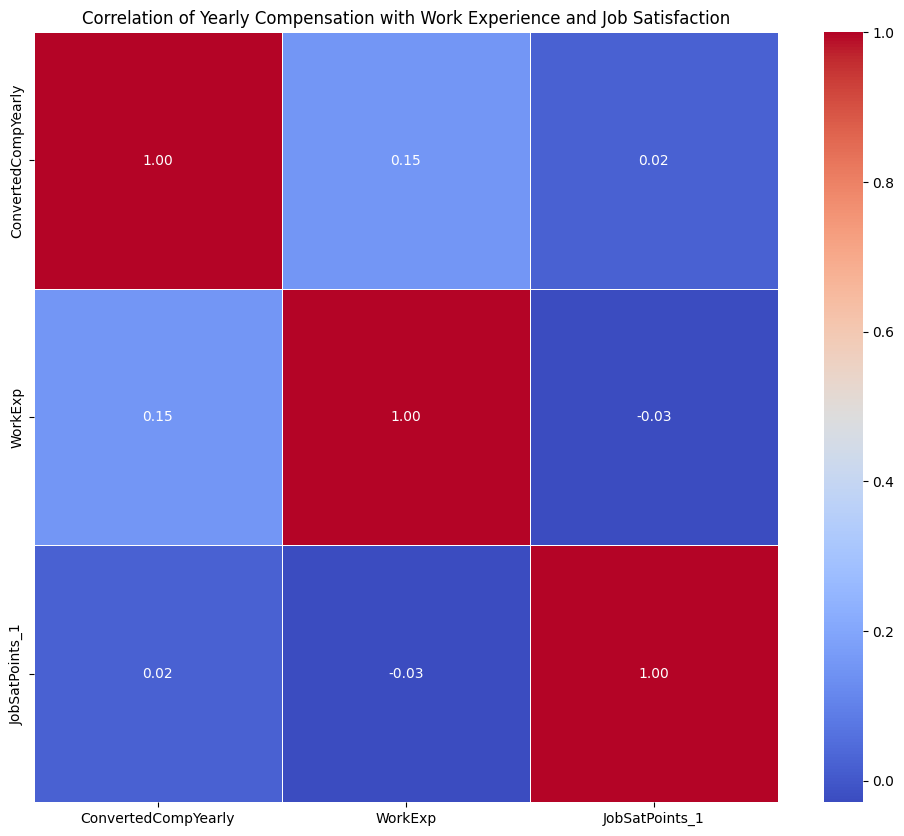

In [7]:
## Write your code here
#df['ConvertedCompYearly'].dtypes #used to see the data types, can uncomment when needed
#df['WorkExp'].dtypes #used to see the data types, can uncomment when needed
#df['JobSatPoints_1'].dtypes #used to see the data types, can uncomment when needed

print (f"the number of nan's in ConvertedCompYearly is {df['ConvertedCompYearly'].isna().sum()}") #used to see how many nan's there are
print (f"the number of nan's in WorkExp is {df['WorkExp'].isna().sum()}") #used to see how many nan's there are
print (f"the number of nan's in WorkExp is {df['JobSatPoints_1'].isna().sum()}") #used to see how many nan's there are

#First need to remove nan's from WorkExp and JobSatPoints_1 column
df = df.dropna(subset=['WorkExp', 'JobSatPoints_1'])

print (f"the updated number of nan's in ConvertedCompYearly is {df['ConvertedCompYearly'].isna().sum()}") #used to see how many nan's there are
print (f"the updated number of nan's in WorkExp is {df['WorkExp'].isna().sum()}") #used to see how many nan's there are
print (f"the updated number of nan's in WorkExp is {df['JobSatPoints_1'].isna().sum()}") #used to see how many nan's there are

#Select columns for correlation analysis
corr_matrix = df[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].corr()

#plot a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5) #fmt = '.2f' shows exactly to decimal places
plt.title('Correlation of Yearly Compensation with Work Experience and Job Satisfaction')
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


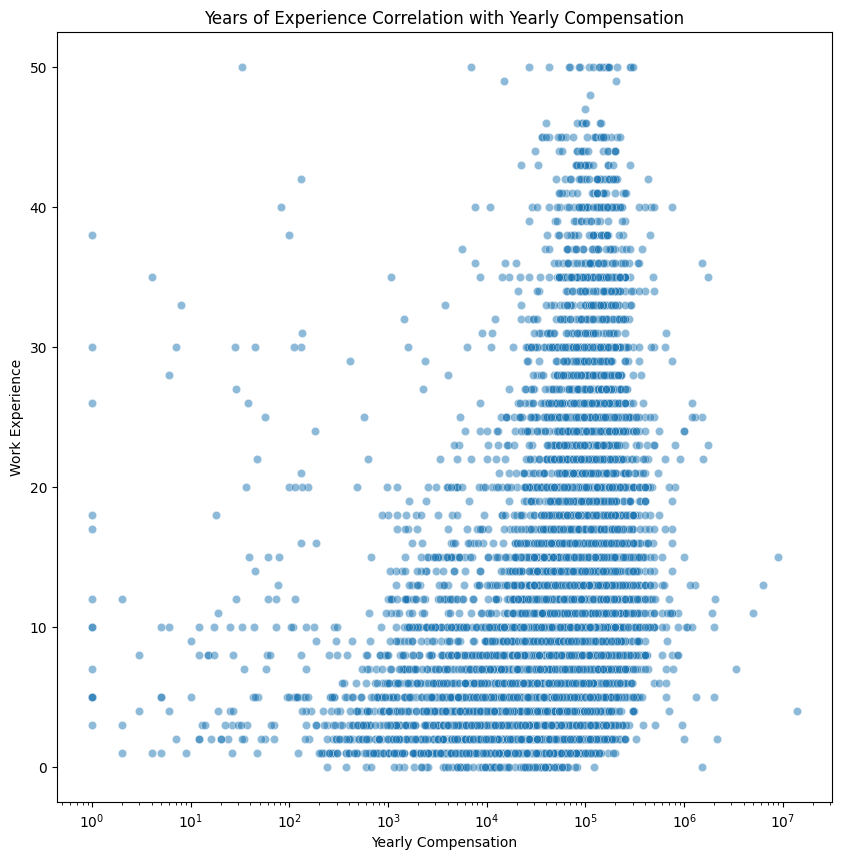

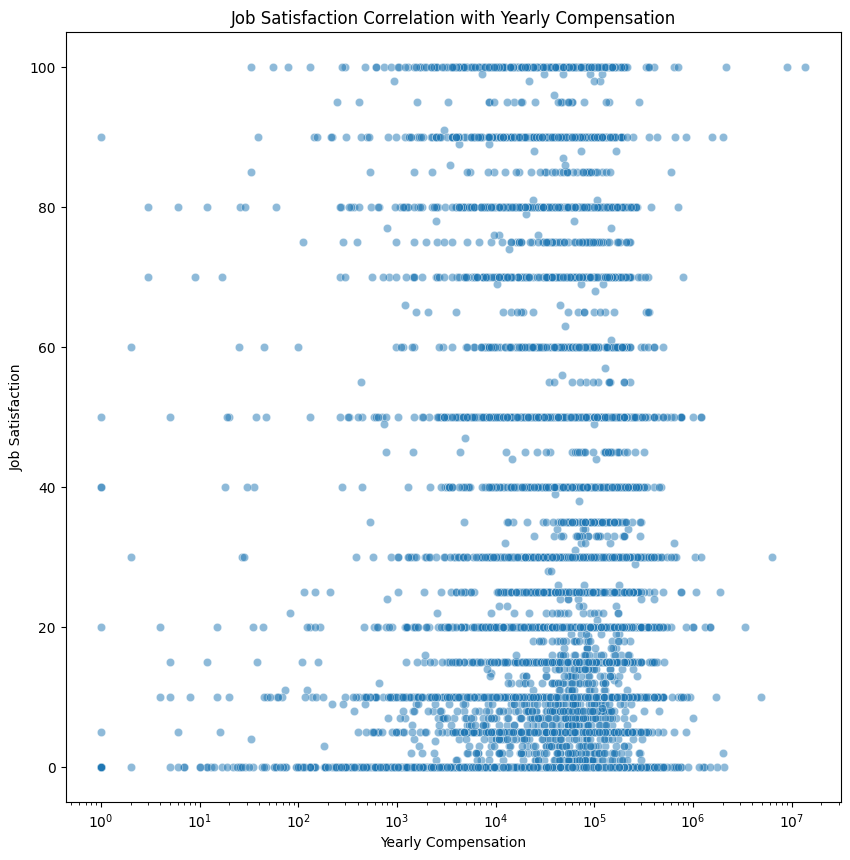

In [12]:
## Write your code here
#Make the first scatter plots
plt.figure(figsize= (10, 10))
ax1 = sns.scatterplot(data = df, x='ConvertedCompYearly', y='WorkExp', alpha = 0.5) #alpha = 0.5 sets the transparancy of data points to 50%

#Setting y axes to log scale
ax1.set_xscale('log')

#add titles and axis labels
plt.title('Years of Experience Correlation with Yearly Compensation')
plt.xlabel('Yearly Compensation')
plt.ylabel('Work Experience')
plt.show()

##
#Make the second scatter plot
plt.figure(figsize= (10, 10))
ax2 = sns.scatterplot(data = df, x='ConvertedCompYearly', y='JobSatPoints_1', alpha = 0.5) #alpha = 0.5 sets the transparancy of data points to 50%

#Setting y axes to log scale
ax2.set_xscale('log')

#add titles and axis labels
plt.title('Job Satisfaction Correlation with Yearly Compensation')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction')
plt.show()



<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
